In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re

In [2]:
def parse_outcar(filename="OUTCAR"):
    potential_energy = None
    computational_time = None

    with open(filename, "r") as f:
        for line in f:
            if "TOTEN" in line:
                # line looks like: "  free  energy   TOTEN  =    -10.123456 eV"
                try:
                    potential_energy = float(line.split()[4])
                except (IndexError, ValueError):
                    continue
            elif "Elapsed time (sec):" in line:
                # line looks like: " Elapsed time (sec):    12345.67"
                try:
                    computational_time = float(line.split()[-1])
                except (IndexError, ValueError):
                    continue

    return potential_energy, computational_time

In [5]:
kpoints = np.linspace(1,9,5)
PE = []
time = []
for i in kpoints:
    pe, t = parse_outcar(str(int(i)))
    PE.append(pe)
    time.append(t)
print(PE)
print(time)

[-855.09738327, -855.11686269, -855.12320607, -855.12702367, -855.12563918]
[328.471, 2798.387, 12774.287, 35078.095, 74975.84]


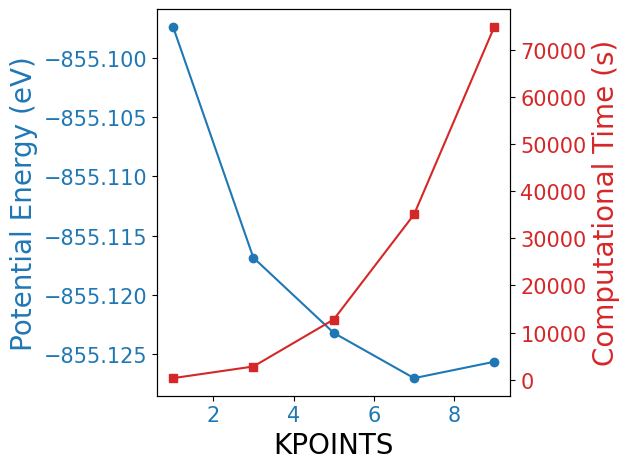

In [6]:
# Create figure and left axis
fig, ax1 = plt.subplots()

# Plot PE vs ENCUT (left y-axis)
color = "tab:blue"
ax1.set_xlabel("KPOINTS", fontsize=20)
ax1.set_ylabel("Potential Energy (eV)", fontsize=20, color=color)
ax1.plot(kpoints, PE, marker="o", color=color, label="PE")
ax1.tick_params(axis="both", labelsize=15, labelcolor=color)

# Create right y-axis
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("Computational Time (s)", fontsize=20, color=color)
ax2.plot(kpoints, time, marker="s", color=color, label="Time")
ax2.tick_params(axis="both", labelsize=15, labelcolor=color)

fig.tight_layout()
plt.show()